# 01 — Exploratory Data Analysis

Q-Factor Prediction in Optical Communication Systems.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_regression
from sklearn.ensemble import IsolationForest
from src.data import load_raw
from src.config import FEATURE_COLS, TARGET_COL, FIGURES_DIR
sns.set_theme(style='whitegrid')

In [2]:
df = load_raw()
print(df.shape)
df.head()

(1000000, 6)


,OSNR,Launch_Power,Fiber_Length,Dispersion,Nonlinear_Effect,Q_Factor
0,0.374540,0.950714,0.731994,0.598658,0.156019,6.035415
1,0.155995,0.058084,0.866176,0.601115,0.708073,4.108890
2,0.020584,0.969910,0.832443,0.212339,0.181825,5.061165
3,0.183405,0.304242,0.524756,0.431945,0.291229,3.628312
4,0.611853,0.139494,0.292145,0.366362,0.456070,4.938192


## Statistik deskriptif

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
OSNR,1000000.0,0.499813,0.288668,3.869667e-07,0.250158,0.499587,0.749862,0.999997
Launch_Power,1000000.0,0.499861,0.288882,3.774576e-07,0.249555,0.499516,0.750173,0.999998
Fiber_Length,1000000.0,0.500446,0.288664,6.783200e-07,0.250427,0.500770,0.750159,0.999999
Dispersion,1000000.0,0.499917,0.288579,3.907137e-07,0.250155,0.499539,0.749759,1.000000
Nonlinear_Effect,1000000.0,0.499897,0.288476,8.328106e-07,0.250291,0.500004,0.749474,0.999999
Q_Factor,1000000.0,5.245744,1.166622,1.985188e+00,4.387901,5.232762,6.057092,9.505047


In [4]:
print('Missing values:', df.isna().sum().sum())
print('Duplicates  :', df.duplicated().sum())

Missing values: 0
Duplicates  : 0


## Distribusi fitur & target

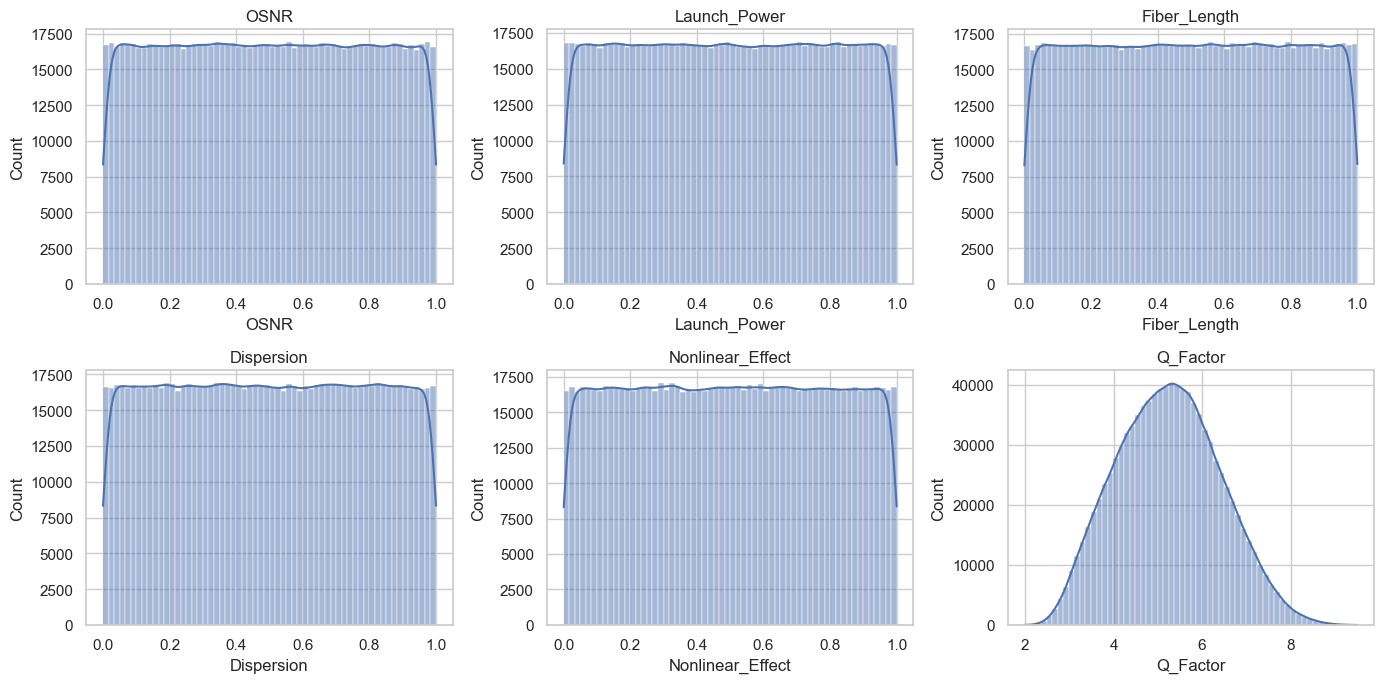

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.ravel(), FEATURE_COLS + [TARGET_COL]):
    sns.histplot(df[col], ax=ax, bins=60, kde=True)
    ax.set_title(col)
plt.tight_layout(); plt.savefig(FIGURES_DIR / '01_distributions.png', dpi=120); plt.show()

## Korelasi Pearson & Spearman

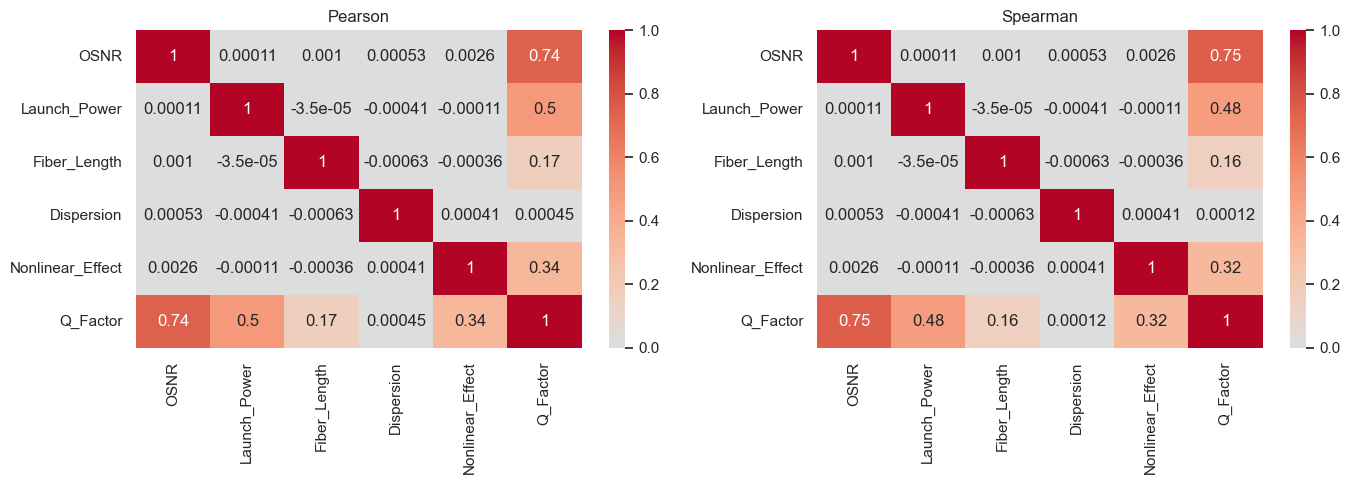

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df.corr(method='pearson'), annot=True, cmap='coolwarm', center=0, ax=axes[0]); axes[0].set_title('Pearson')
sns.heatmap(df.corr(method='spearman'), annot=True, cmap='coolwarm', center=0, ax=axes[1]); axes[1].set_title('Spearman')
plt.tight_layout(); plt.savefig(FIGURES_DIR / '01_correlation.png', dpi=120); plt.show()

## Mutual information

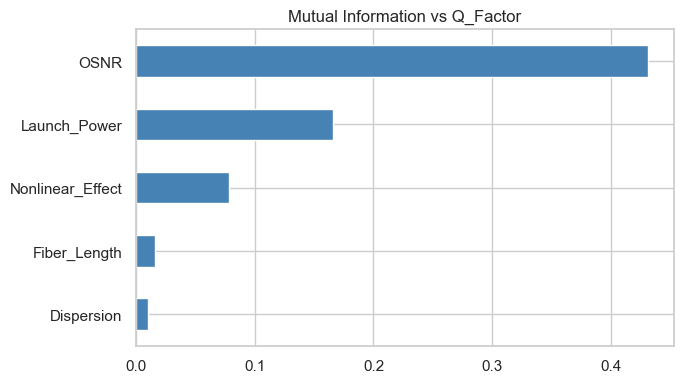

Dispersion          0.010391
Fiber_Length        0.016162
Nonlinear_Effect    0.078615
Launch_Power        0.166078
OSNR                0.431361
dtype: float64

In [7]:
mi = mutual_info_regression(df[FEATURE_COLS].values, df[TARGET_COL].values, random_state=42)
mi_s = pd.Series(mi, index=FEATURE_COLS).sort_values(ascending=True)
mi_s.plot.barh(figsize=(7, 4), color='steelblue')
plt.title('Mutual Information vs Q_Factor'); plt.tight_layout()
plt.savefig(FIGURES_DIR / '01_mutual_info.png', dpi=120); plt.show()
mi_s

## Outlier detection (Isolation Forest pada subsample)

In [8]:
sub = df.sample(50_000, random_state=42)
iso = IsolationForest(contamination=0.01, random_state=42).fit(sub[FEATURE_COLS])
anom = (iso.predict(sub[FEATURE_COLS]) == -1).mean()
print(f'Anomaly fraction: {anom:.3%}')

Anomaly fraction: 1.000%


## Uji normalitas target (D'Agostino)

In [9]:
stat, p = stats.normaltest(df[TARGET_COL].sample(50_000, random_state=42))
print(f'D\u2019Agostino stat={stat:.2f}, p={p:.3e}')

D’Agostino stat=755.68, p=8.067e-165


## Pair-plot pada subsample

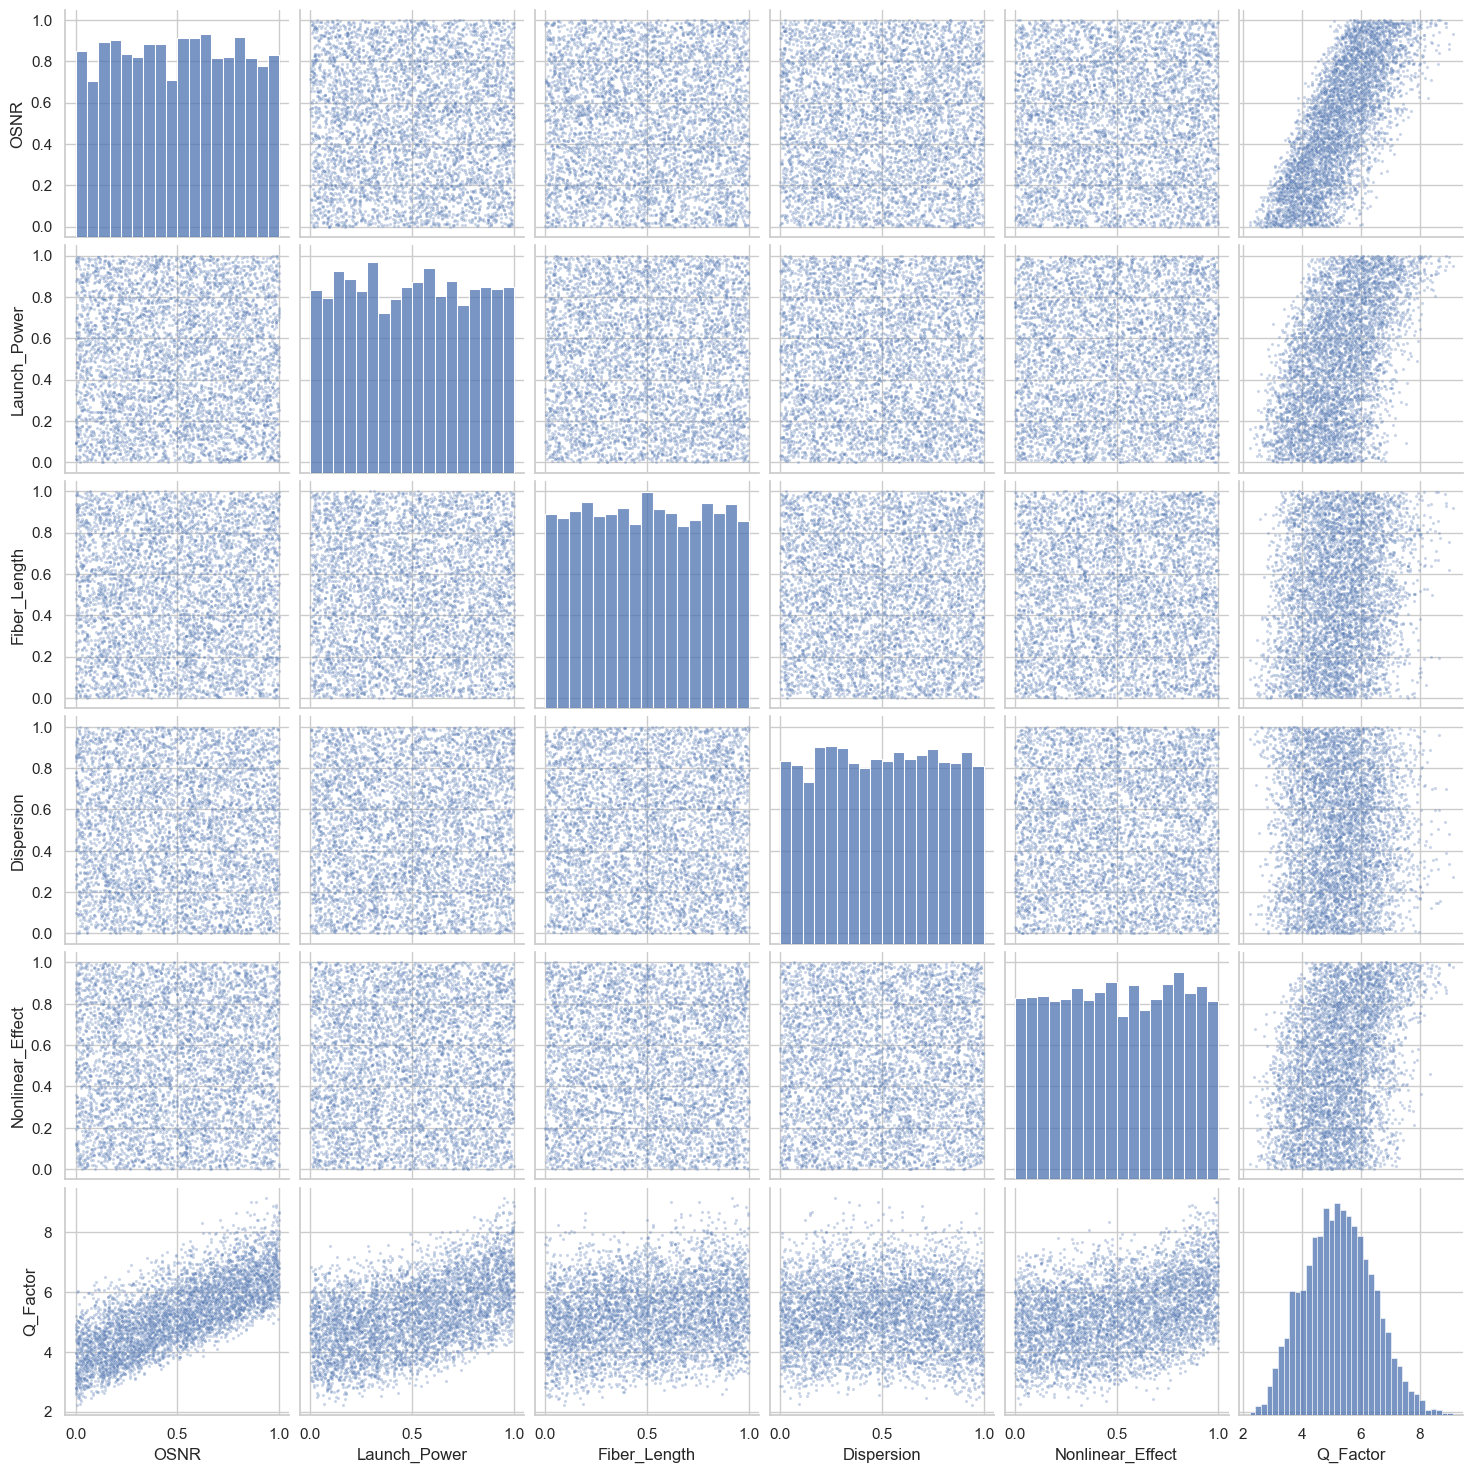

In [10]:
g = sns.pairplot(df.sample(5_000, random_state=42), vars=FEATURE_COLS + [TARGET_COL], plot_kws={'s': 5, 'alpha': 0.3})
g.fig.savefig(FIGURES_DIR / '01_pairplot.png', dpi=100)